In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

# ============================================================
# Config
# ============================================================

LOW_FILE = "smart_charging_decisions_low.csv"
HIGH_FILE = "smart_charging_decisions_high.csv"
DYNAMIC_FILE = "smart_charging_decisions_dynamic.csv"

OUT_DIR = Path("smart_charging_figures")
OUT_DIR.mkdir(exist_ok=True)

END_HOUR = 30
DEFAULT_STEP_SECONDS = 300

# 这里定义你要展示的价格曲线
# 如果你后面改了实验里的价格，可以直接改这里
PRICE_PROFILES = {
    "low": [
        (0, 0.10),
        (END_HOUR, 0.10),
    ],
    "high": [
        (0, 0.30),
        (END_HOUR, 0.30),
    ],
    "dynamic": [
        (0, 0.20),
        (17, 0.20),
        (17, 0.45),
        (22, 0.45),
        (22, 0.10),
        (24, 0.10),
        (24, 0.20),
        (END_HOUR, 0.20),
    ],
}

DECISION_COLORS = {
    "price_acceptable": "#1f77b4",
    "wait_price_high": "#ff7f0e",
    "urgent": "#2ca02c",
    "target_soc_reached": "#7f7f7f",
    "away": "#bdbdbd",
}

CASE_COLORS = {
    "low": "#1f77b4",
    "high": "#ff7f0e",
    "dynamic": "#2ca02c",
}

AWAY_SHADE_COLOR = "lightgray"
AWAY_SHADE_ALPHA = 0.25


# ============================================================
# Basic helpers
# ============================================================

def load_case(path):
    df = pd.read_csv(path).copy()

    # 兼容 household 列是字符串或布尔
    if df["household"].dtype == object:
        df["household"] = df["household"].astype(str).str.lower().map({
            "true": True,
            "false": False
        })
    else:
        df["household"] = df["household"].astype(bool)

    df["tick"] = pd.to_numeric(df["tick"])
    df["hour"] = df["tick"] / 3600.0
    df["duration"] = pd.to_numeric(df["duration"])
    df["finalPowerKW"] = pd.to_numeric(df["finalPowerKW"])
    df["socRatio"] = pd.to_numeric(df["socRatio"], errors="coerce")
    df["deficitJ"] = pd.to_numeric(df["deficitJ"], errors="coerce")

    return df


def get_step_seconds(df):
    ticks = np.sort(df["tick"].unique())
    if len(ticks) < 2:
        return DEFAULT_STEP_SECONDS
    diffs = np.diff(ticks)
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return DEFAULT_STEP_SECONDS
    return int(pd.Series(diffs).mode().iloc[0])


def price_profile_to_step(profile_name):
    pairs = PRICE_PROFILES[profile_name]
    hours = [x[0] for x in pairs]
    prices = [x[1] for x in pairs]
    return hours, prices


def get_price_at_hour(profile_name, hour):
    pairs = PRICE_PROFILES[profile_name]
    current_price = pairs[0][1]
    for h, p in pairs:
        if hour >= h:
            current_price = p
        else:
            break
    return current_price


def build_full_tick_index(df, end_hour=END_HOUR, step_seconds=DEFAULT_STEP_SECONDS):
    regular_ticks = np.arange(0, end_hour * 3600 + step_seconds, step_seconds)
    actual_ticks = df["tick"].unique()
    full_ticks = np.unique(np.concatenate([regular_ticks, actual_ticks]))
    return np.sort(full_ticks)


def build_aggregate_load(df, end_hour=END_HOUR):
    hh = df[df["household"] == True].copy()
    step_seconds = get_step_seconds(hh)
    full_ticks = build_full_tick_index(hh, end_hour=end_hour, step_seconds=step_seconds)

    agg = hh.groupby("tick")["finalPowerKW"].sum().reset_index()
    out = pd.DataFrame({"tick": full_ticks})
    out = out.merge(agg, on="tick", how="left")
    out["finalPowerKW"] = out["finalPowerKW"].fillna(0.0)
    out["hour"] = out["tick"] / 3600.0
    out = out.sort_values("tick").reset_index(drop=True)
    out.rename(columns={"finalPowerKW": "household_ev_load_kw"}, inplace=True)
    return out


def build_cumulative_energy(df, end_hour=END_HOUR):
    hh = df[df["household"] == True].copy()
    step_seconds = get_step_seconds(hh)
    full_ticks = build_full_tick_index(hh, end_hour=end_hour, step_seconds=step_seconds)

    hh["energy_kwh"] = hh["finalPowerKW"] * hh["duration"] / 3600.0
    agg = hh.groupby("tick")["energy_kwh"].sum().reset_index()

    out = pd.DataFrame({"tick": full_ticks})
    out = out.merge(agg, on="tick", how="left")
    out["energy_kwh"] = out["energy_kwh"].fillna(0.0)
    out["cum_energy_kwh"] = out["energy_kwh"].cumsum()
    out["hour"] = out["tick"] / 3600.0
    out = out.sort_values("tick").reset_index(drop=True)
    return out


def active_decision_summary(df):
    hh = df[df["household"] == True].copy()
    active = hh[hh["deficitJ"] > 0].copy()

    counts = active["decision"].value_counts().to_dict()
    total = sum(counts.get(k, 0) for k in ["price_acceptable", "wait_price_high", "urgent"])

    if total == 0:
        return {
            "price_acceptable": 0.0,
            "wait_price_high": 0.0,
            "urgent": 0.0,
        }

    return {
        "price_acceptable": 100.0 * counts.get("price_acceptable", 0) / total,
        "wait_price_high": 100.0 * counts.get("wait_price_high", 0) / total,
        "urgent": 100.0 * counts.get("urgent", 0) / total,
    }


def add_price_change_markers(ax):
    markers = [
        (17, "high price starts"),
        (22, "low price starts"),
        (24, "returns to medium"),
    ]
    ymin, ymax = ax.get_ylim()
    for x, label in markers:
        ax.axvline(x, linestyle="--", linewidth=1, color="black", alpha=0.5)
        ax.text(x + 0.1, ymax - 0.05 * (ymax - ymin), label, fontsize=9, va="top")


def add_away_shading(ax, story):
    """
    灰色阴影 = 车辆不在家，因此 household response model 没有被触发
    """
    away = (~story["at_home"]).values
    hours = story["hour"].values

    start = None
    for i, flag in enumerate(away):
        if flag and start is None:
            start = hours[i]
        elif (not flag) and start is not None:
            ax.axvspan(start, hours[i], color=AWAY_SHADE_COLOR, alpha=AWAY_SHADE_ALPHA)
            start = None

    if start is not None:
        ax.axvspan(start, hours[-1], color=AWAY_SHADE_COLOR, alpha=AWAY_SHADE_ALPHA)


def away_legend_handle():
    return Patch(
        facecolor=AWAY_SHADE_COLOR,
        edgecolor="none",
        alpha=AWAY_SHADE_ALPHA,
        label="Away from home / model inactive"
    )


# ============================================================
# Figure 1: overall system comparison
# ============================================================

def plot_figure_1(data):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    # (a) price profiles
    ax = axes[0]
    for case in ["low", "high", "dynamic"]:
        h, p = price_profile_to_step(case)
        ax.step(h, p, where="post", label=case, color=CASE_COLORS[case])
    ax.set_title("(a) Price profiles")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Price")
    ax.set_xlim(0, END_HOUR)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # (b) aggregate household EV load
    ax = axes[1]
    for case in ["low", "high", "dynamic"]:
        agg = build_aggregate_load(data[case])
        ax.step(
            agg["hour"],
            agg["household_ev_load_kw"],
            where="post",
            label=case,
            color=CASE_COLORS[case]
        )
    ax.set_title("(b) Aggregate household EV load")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Load (kW)")
    ax.set_xlim(0, END_HOUR)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # (c) cumulative charging energy
    ax = axes[2]
    for case in ["low", "high", "dynamic"]:
        cum = build_cumulative_energy(data[case])
        ax.step(
            cum["hour"],
            cum["cum_energy_kwh"],
            where="post",
            label=case,
            color=CASE_COLORS[case]
        )
    ax.set_title("(c) Cumulative household charging energy")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Energy (kWh)")
    ax.set_xlim(0, END_HOUR)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # (d) active decision mix
    ax = axes[3]
    cases = ["low", "high", "dynamic"]
    summary = {case: active_decision_summary(data[case]) for case in cases}

    bottom = np.zeros(len(cases))
    for decision in ["price_acceptable", "wait_price_high", "urgent"]:
        values = [summary[c][decision] for c in cases]
        ax.bar(
            cases,
            values,
            bottom=bottom,
            label=decision,
            color=DECISION_COLORS[decision]
        )
        bottom += np.array(values)

    ax.set_title("(d) Active decision mix")
    ax.set_ylabel("Share of active rows (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend()

    plt.tight_layout()
    out = OUT_DIR / "fig1_system_comparison.png"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.close()
    print(f"Saved {out}")


# ============================================================
# Figure 2: dynamic case segment response
# ============================================================

def plot_figure_2(data):
    df = data["dynamic"].copy()
    hh = df[df["household"] == True].copy()
    active = hh[hh["deficitJ"] > 0].copy()

    if len(active) == 0:
        print("No active household rows in dynamic case, skip Figure 2")
        return

    if "userSegment" not in active.columns:
        print("Column 'userSegment' not found, skip Figure 2")
        return

    summary = (
        active.groupby(["price", "userSegment", "decision"])
        .size()
        .reset_index(name="count")
        .sort_values(["price", "userSegment", "decision"])
    )

    # 只保留真正 active 的三个决策
    summary = summary[summary["decision"].isin(["price_acceptable", "wait_price_high", "urgent"])].copy()

    # 构造 x 轴标签
    summary["x_label"] = summary["price"].map(lambda x: f"{x:.2f}") + "\n" + summary["userSegment"]

    x_order = []
    for p in sorted(summary["price"].unique()):
        for seg in sorted(summary["userSegment"].unique()):
            label = f"{p:.2f}\n{seg}"
            if ((summary["price"] == p) & (summary["userSegment"] == seg)).any():
                x_order.append(label)

    pivot = (
        summary.pivot_table(
            index="x_label",
            columns="decision",
            values="count",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(x_order)
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(15, 6))

    bottom = np.zeros(len(pivot))
    for decision in ["price_acceptable", "wait_price_high", "urgent"]:
        vals = pivot[decision] if decision in pivot.columns else np.zeros(len(pivot))
        ax.bar(
            np.arange(len(pivot)),
            vals,
            bottom=bottom,
            color=DECISION_COLORS[decision],
            label=decision
        )
        bottom += np.array(vals)

    ax.set_xticks(np.arange(len(pivot)))
    ax.set_xticklabels(pivot.index, rotation=35, ha="right")
    ax.set_ylabel("Number of active decision rows")
    ax.set_title("Figure 2. Active household charging decisions by price and user segment (dynamic case)")
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend()

    plt.tight_layout()
    out = OUT_DIR / "fig2_segment_response_dynamic.png"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.close()
    print(f"Saved {out}")


# ============================================================
# Figure 3: single-vehicle case study
# ============================================================

def choose_story_vehicle(dynamic_df):
    hh = dynamic_df[dynamic_df["household"] == True].copy()
    active = hh[hh["deficitJ"] > 0].copy()

    if len(active) == 0:
        # fallback
        counts = hh["vehicle"].value_counts()
        return counts.index[0]

    rows = []
    for vid, g in active.groupby("vehicle"):
        decisions = set(g["decision"].tolist())
        score = 0

        # 最优先：既有等待，又有充电
        if "wait_price_high" in decisions:
            score += 100
        if "price_acceptable" in decisions:
            score += 80
        if "urgent" in decisions:
            score += 60

        # active rows 多一点更适合讲故事
        score += len(g)

        rows.append({
            "vehicle": vid,
            "score": score,
            "n_rows": len(g),
            "decisions": ",".join(sorted(decisions))
        })

    story_df = pd.DataFrame(rows).sort_values(["score", "n_rows"], ascending=False)
    return story_df.iloc[0]["vehicle"]


def build_story_timeline(v, price_profile_name="dynamic", end_hour=END_HOUR):
    v = v.sort_values("tick").copy()
    step_seconds = get_step_seconds(v)
    full_ticks = build_full_tick_index(v, end_hour=end_hour, step_seconds=step_seconds)

    out = pd.DataFrame({"tick": full_ticks})
    out["hour"] = out["tick"] / 3600.0

    keep_cols = [
        "tick", "price", "decision", "finalPowerKW", "socRatio",
        "targetSocRatio", "acceptedPriceThreshold"
    ]
    keep_cols = [c for c in keep_cols if c in v.columns]

    out = out.merge(v[keep_cols], on="tick", how="left")

    # 如果没有 price，就按定义的 profile 补
    if "price" not in out.columns or out["price"].isna().all():
        out["price"] = out["hour"].apply(lambda h: get_price_at_hour(price_profile_name, h))
    else:
        out["price"] = out["price"].fillna(out["hour"].apply(lambda h: get_price_at_hour(price_profile_name, h)))

    out["at_home"] = out["decision"].notna()
    out["decision_plot"] = out["decision"].fillna("away")
    out["finalPowerKW"] = out["finalPowerKW"].fillna(0.0)

    return out


def plot_figure_3(data):
    dynamic = data["dynamic"].copy()
    vehicle_id = choose_story_vehicle(dynamic)

    hh = dynamic[dynamic["household"] == True].copy()
    v = hh[hh["vehicle"].astype(str) == str(vehicle_id)].copy().sort_values("tick").reset_index(drop=True)

    story = build_story_timeline(v, price_profile_name="dynamic", end_hour=END_HOUR)

    fig, axes = plt.subplots(5, 1, figsize=(16, 16), sharex=True)

    # shared legend handle for gray area
    away_handle = away_legend_handle()

    # (a) full-day price
    ax = axes[0]
    h, p = price_profile_to_step("dynamic")
    ax.step(h, p, where="post", color=CASE_COLORS["dynamic"], label="dynamic price")
    ax.set_title(f"(a) Full-day dynamic price for household EV {vehicle_id}")
    ax.set_ylabel("Price")
    ax.set_xlim(0, END_HOUR)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    # (b) availability
    ax = axes[1]
    ax.step(story["hour"], story["at_home"].astype(int), where="post", color="black", label="home availability")
    add_away_shading(ax, story)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["away", "at home"])
    ax.set_ylabel("Availability")
    ax.set_title("(b) Whether the vehicle is at home")
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0], [0], color="black", label="At-home status"),
        away_handle
    ], loc="upper right")

    # (c) charging power
    ax = axes[2]
    ax.step(story["hour"], story["finalPowerKW"], where="post", color="#1f77b4", label="charging power")
    add_away_shading(ax, story)
    ax.set_ylabel("Power (kW)")
    ax.set_title("(c) Charging power response")
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0], [0], color="#1f77b4", label="Charging power"),
        away_handle
    ], loc="upper right")

    # (d) SOC
    ax = axes[3]
    home_points = story[story["at_home"]].copy()

    if len(home_points) > 0:
        ax.plot(
            home_points["hour"],
            home_points["socRatio"],
            marker="o",
            markersize=2,
            linewidth=1.5,
            color="#1f77b4",
            label="Observed SOC at home"
        )

        if "targetSocRatio" in home_points.columns and home_points["targetSocRatio"].notna().any():
            target_soc = home_points["targetSocRatio"].dropna().iloc[0]
        else:
            target_soc = 0.80

        ax.axhline(target_soc, linestyle="--", color="black", linewidth=1, label="Target SOC")

    add_away_shading(ax, story)
    ax.set_ylabel("SOC ratio")
    ax.set_title("(d) SOC observed when the vehicle is at home")
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0], [0], color="#1f77b4", marker="o", markersize=4, linewidth=1.5, label="Observed SOC at home"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=1, label="Target SOC"),
        away_handle
    ], loc="upper right")

    # (e) decision state
    decision_map = {
        "away": -1,
        "target_soc_reached": 0,
        "wait_price_high": 1,
        "price_acceptable": 2,
        "urgent": 3,
    }
    story["decision_code"] = story["decision_plot"].map(decision_map)

    ax = axes[4]
    ax.step(story["hour"], story["decision_code"], where="post", color="#1f77b4", label="decision state")
    add_away_shading(ax, story)
    ax.set_yticks([-1, 0, 1, 2, 3])
    ax.set_yticklabels(["away", "target", "wait", "charge", "urgent"])
    ax.set_ylabel("Decision")
    ax.set_xlabel("Hour of day")
    ax.set_title("(e) Charging decision state")
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0], [0], color="#1f77b4", label="Decision state line"),
        away_handle
    ], loc="upper right")

    for ax in axes:
        ax.set_xlim(0, END_HOUR)

    fig.suptitle(
        "Figure 3. Single-vehicle case study\n"
        "Gray shaded intervals mean the vehicle is away from home, so the household charging response model is inactive.",
        fontsize=14,
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    out = OUT_DIR / "fig3_vehicle_case_study.png"
    plt.savefig(out, dpi=220, bbox_inches="tight")
    plt.close()
    print(f"Saved {out}")
    print(f"Chosen case-study vehicle: {vehicle_id}")


# ============================================================
# Main
# ============================================================

def main():
    data = {
        "low": load_case(LOW_FILE),
        "high": load_case(HIGH_FILE),
        "dynamic": load_case(DYNAMIC_FILE),
    }

    print("Loaded files:")
    for k, df in data.items():
        print(f"  {k}: rows={len(df)} household_rows={(df['household'] == True).sum()}")

    plot_figure_1(data)
    plot_figure_2(data)
    plot_figure_3(data)

    print("\nDone.")
    print(f"All figures saved to: {OUT_DIR.resolve()}")


if __name__ == "__main__":
    main()

Loaded files:
  low: rows=3135 household_rows=2981
  high: rows=5258 household_rows=5058
  dynamic: rows=2472 household_rows=2383
Saved smart_charging_figures/fig1_system_comparison.png
Column 'userSegment' not found, skip Figure 2
Saved smart_charging_figures/fig3_vehicle_case_study.png
Chosen case-study vehicle: 212-1

Done.
All figures saved to: /Users/yu/Desktop/beam/smart_charging_figures


smart_charging_figures/fig1_system_comparison.png


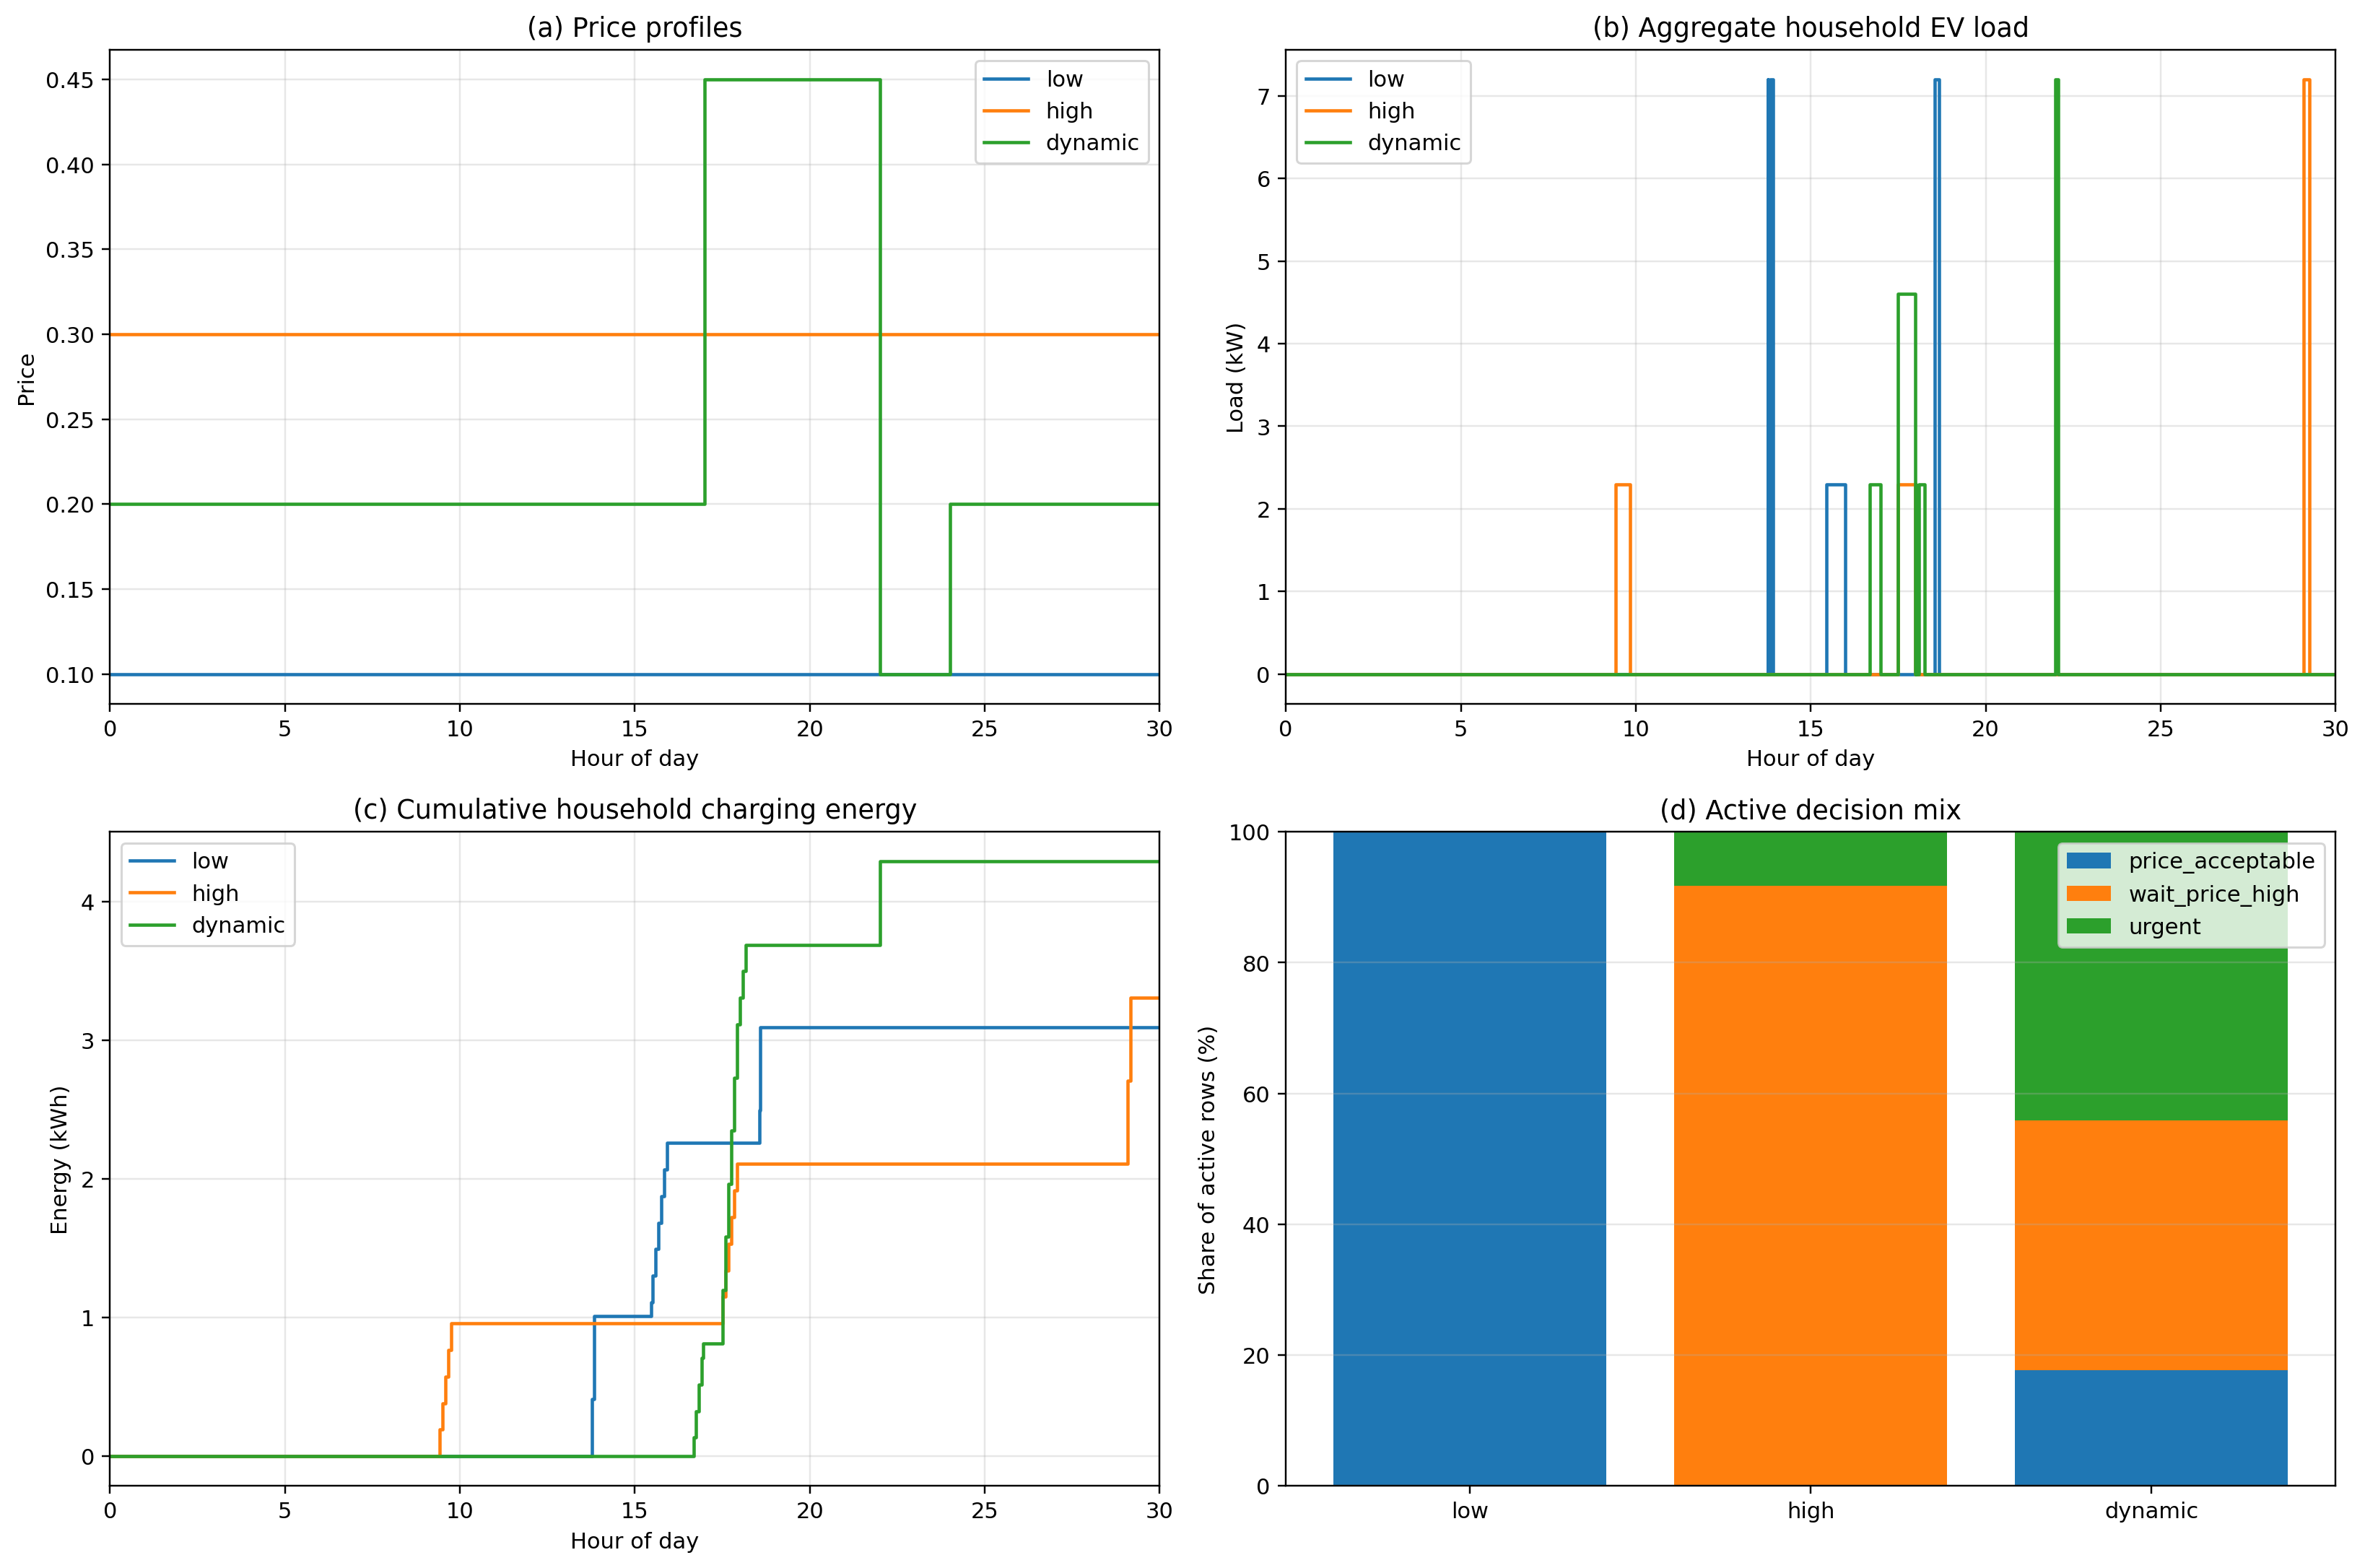

smart_charging_figures/fig2_segment_response_dynamic.png
File not found: smart_charging_figures/fig2_segment_response_dynamic.png
smart_charging_figures/fig3_vehicle_case_study.png


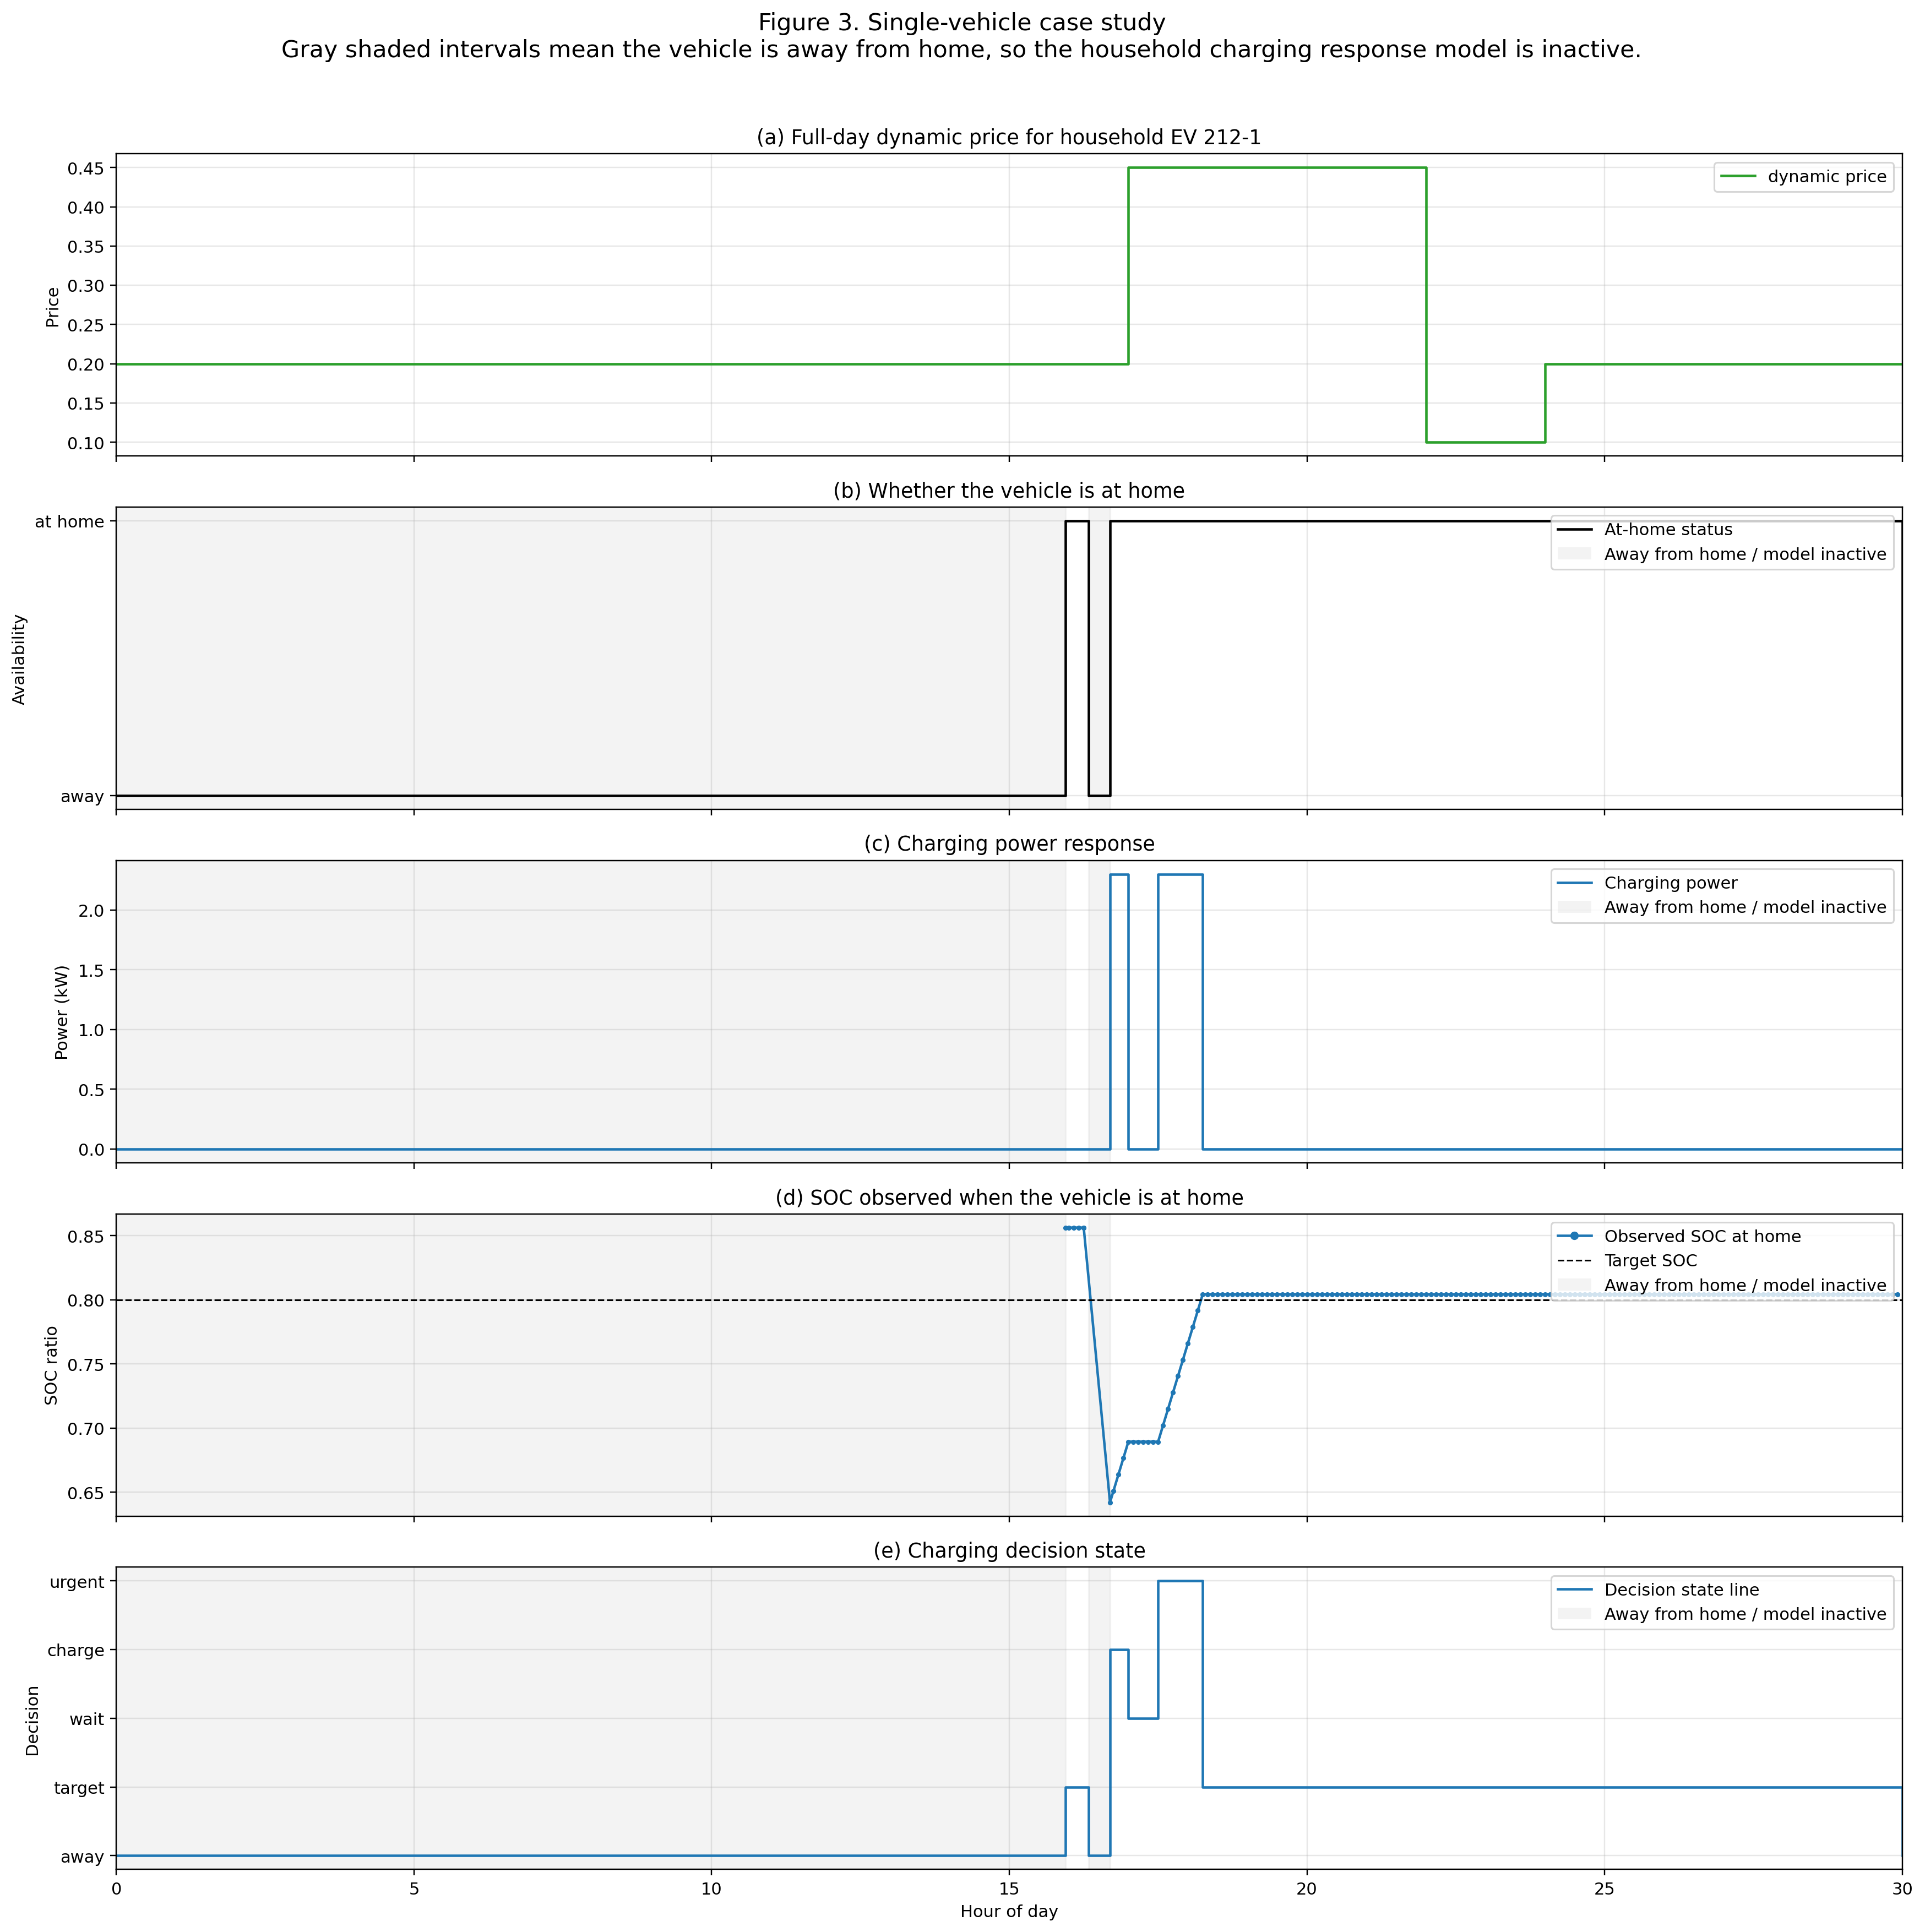

In [15]:
from IPython.display import Image, display
from pathlib import Path

fig_dir = Path("smart_charging_figures")

figures = [
    fig_dir / "fig1_system_comparison.png",
    fig_dir / "fig2_segment_response_dynamic.png",
    fig_dir / "fig3_vehicle_case_study.png",
]

for fig in figures:
    print("=" * 80)
    print(fig)
    if fig.exists():
        display(Image(filename=str(fig)))
    else:
        print("File not found:", fig)